In [209]:
# Project 1  Marketing Campaign
# Description

# Problem scenario: 
# Marketing mix stands as a widely utilized concept in the execution of marketing strategies. It encompasses various facets within a comprehensive marketing plan, with a central focus on the four Ps of marketing: product, price, place, and promotion.

# Problem objective:
# As a data scientist, you must conduct exploratory data analysis and hypothesis testing to enhance your comprehension of the diverse factors influencing customer acquisition.

# Data description:
# The variables such as birth year, education, income, and others pertain to the first 'P' or 'People' in the tabular data presented to the user. 
# The expenditures on items like wine, fruits, and gold, are associated with ‘Product’. 
# Information relevant to sales channels, such as websites and stores, is connected to ‘Place’, and the fields discussing promotions and the outcomes of various campaigns are linked to ‘Promotion’.

In [210]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
import scipy.stats as stats

In [211]:
df = pd.read_csv("marketing_data.csv")

In [212]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [213]:
# Let's us get some statistical info about data
df.describe()

,ID,Year_Birth,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.149107,0.009375
std,3246.662198,11.984069,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.356274,0.096391
min,0.000000,1893.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [214]:
#Let us also have a look at the metadata
df.info()
# Removing trailing spaces from column names
# df.columns = df.columns.str.strip()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

In [215]:
#Let us also have a look at the metadata
df.info()
# Removing trailing spaces from column names
df.columns = df.columns.str.strip()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

In [216]:
# Below is the data dictionary which provide insights about each column
data_dictionary = {
    "ID": "Customer's unique identifier",
    "Year_Birth": "Customer's birth year",
    "Education": "Customer's education level",
    "Marital_Status": "Customer's marital status",
    "Income": "Customer's yearly household income",
    "Kidhome": "Number of small children in customer's household",
    "Teenhome": "Number of teenagers in customer's household",
    "Dt_Customer": "Date of customer's enrollment with the company",
    "Recency": "Number of days since the last purchase",
    "MntWines": "Amount spent on wine in last 2 years",
    "MntFruits": "Amount spent on fruits in last 2 years",
    "MntMeatProducts": "Amount spent on meat products in last 2 years",
    "MntFishProducts": "Amount spent on fish products in last 2 years",
    "MntSweetProducts": "Amount spent on sweet products in last 2 years",
    "MntGoldProds": "Amount spent on gold in last 2 years",
    "NumDealsPurchases": "Number of purchases made with discount",
    "NumWebPurchases": "Number of purchases made through company's website",
    "NumCatalogPurchases": "Number of purchases made using catalogue",
    "NumStorePurchases": "Number of purchases made directly in store",
    "NumWebVisitsMonth": "Number of visits to company's website in the last month",
    "AcceptedCmp1": "1 if the customer accepted the offer in the 1st campaign, 0 otherwise",
    "AcceptedCmp2": "1 if the customer accepted the offer in the 2nd campaign, 0 otherwise",
    "AcceptedCmp3": "1 if the customer accepted the offer in the 3rd campaign, 0 otherwise",
    "AcceptedCmp4": "1 if the customer accepted the offer in the 4th campaign, 0 otherwise",
    "AcceptedCmp5": "1 if the customer accepted the offer in the 5th campaign, 0 otherwise",
    "Response": "1 if the customer accepted the offer in the last campaign, 0 otherwise",
    "Complain": "1 if customer complained in the last 2 years",
    "Country": "Customer's location"
}
# Objective 
# Analyze the marketing data to uncover patterns in who the customers are, what they buy, where they shop, and which promotions they respond to, in order to improve future marketing strategies.


In [217]:
# Let us do some initial clean up
# 1 Check for null values
df.isnull().sum()
# As we can see only the income column has 24 null values
# Now we will have to fill up these values
# Income is actually the customers household income and not individual income, so if the customer is married, there are chances that both the members are earning

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Response                0
Complain                0
Country                 0
dtype: int64

In [218]:
# Before populating income let'us remove columns that are irrevelant or replace them 
# Age instead of year birth
# Year of birth is a raw attribute.

# Age gives immediate context — how old the person is today (or at a given reference point).

# Using Year_Birth directly in analysis leads to confusing or reversed correlations (e.g., younger customers have higher Year_Birth, but lower age).

# Most business insights and hypotheses (like “older customers prefer in-store shopping”) are naturally phrased in terms of age, not birth year.
df['Age'] = 2025 - df["Year_Birth"]
df.drop(columns=["Year_Birth"], inplace=True)

In [219]:
# Now we have 5 different campaigns and 1 response column
# Since we do not have much information on whether this campaign was for same product (highly unlikely) or different product
# The same customer has reponsded to mutiplte campaigns so its highly likely that all the campaigns where for different products.
# The response column depicts whether the customer responded to last campaign or not ( 5th campaign is not the last campaign), so this must be the 6th and last campaign
# So instead of having 6 cloumns we can have only 1 column which depicts overall customer engagement to the 6 campaigns

df["OverallCustomerEngagement"] = df[["AcceptedCmp3","AcceptedCmp4","AcceptedCmp5",	"AcceptedCmp1","AcceptedCmp2","Response"]].sum(axis=1)

In [220]:
# drop 6 columns
df.drop(columns=["AcceptedCmp3","AcceptedCmp4","AcceptedCmp5",	"AcceptedCmp1","AcceptedCmp2"], inplace=True) #Not dropping response as of now as we need it for further calculations
df.head()

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Country,Age,OverallCustomerEngagement
0,1826,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,104,...,1,4,4,6,1,1,0,SP,55,1
1,1,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,5,...,1,7,3,7,5,1,0,CA,64,2
2,10476,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,11,...,1,3,2,5,2,0,0,US,67,0
3,1386,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,0,...,1,1,0,2,7,0,0,AUS,58,0
4,5371,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,16,...,2,3,1,2,7,1,0,SP,36,2


In [221]:
#Let us populate the missing values in income
# 'Income' in df.columns  # Should return True
# Stripping spaces from income values
df['Income'] = df['Income'].str.strip()
#making it a numeric value
df['Income'] = df['Income'].replace([r'[\$,]'],'', regex=True).astype('float')


In [222]:
#Now we will fill the empty values of income, Income majorly depends on the education (higher the degree more the income) and marital_status (if a person is married chances is their spouse also works so househol income would be double)
df['Income'] = df.groupby(['Marital_Status', 'Education'])['Income'].transform(lambda x: x.fillna(x.median()))

In [223]:
df.isna().sum() # No null columns left

ID                           0
Education                    0
Marital_Status               0
Income                       0
Kidhome                      0
Teenhome                     0
Dt_Customer                  0
Recency                      0
MntWines                     0
MntFruits                    0
MntMeatProducts              0
MntFishProducts              0
MntSweetProducts             0
MntGoldProds                 0
NumDealsPurchases            0
NumWebPurchases              0
NumCatalogPurchases          0
NumStorePurchases            0
NumWebVisitsMonth            0
Response                     0
Complain                     0
Country                      0
Age                          0
OverallCustomerEngagement    0
dtype: int64

In [224]:
#Let us create a new mapping for marital_status and education
df["Marital_Status"].unique()


array(['Divorced', 'Single', 'Married', 'Together', 'Widow', 'YOLO',
       'Alone', 'Absurd'], dtype=object)

In [225]:
def clean_marital_status(x):
    if x in ['Married','Together']:
        return 'Partnered'
    else:
        return 'Single'
    
df["Marital_Status"] = df["Marital_Status"].apply(clean_marital_status)
df

,ID,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Country,Age,OverallCustomerEngagement
0,1826,Graduation,Single,84835.0,0,0,6/16/14,0,189,104,...,1,4,4,6,1,1,0,SP,55,1
1,1,Graduation,Single,57091.0,0,0,6/15/14,0,464,5,...,1,7,3,7,5,1,0,CA,64,2
2,10476,Graduation,Partnered,67267.0,0,1,5/13/14,0,134,11,...,1,3,2,5,2,0,0,US,67,0
3,1386,Graduation,Partnered,32474.0,1,1,5/11/14,0,10,0,...,1,1,0,2,7,0,0,AUS,58,0
4,5371,Graduation,Single,21474.0,1,0,4/8/14,0,6,16,...,2,3,1,2,7,1,0,SP,36,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,PhD,Single,66476.0,0,1,3/7/13,99,372,18,...,2,5,2,11,4,0,0,US,49,0
2236,5263,2n Cycle,Partnered,31056.0,1,0,1/22/13,99,5,10,...,1,1,0,3,8,0,0,SP,48,0
2237,22,Graduation,Single,46310.0,1,0,12/3/12,99,185,2,...,2,6,1,5,8,0,0,SP,49,0
2238,528,Graduation,Partnered,65819.0,0,0,11/29/12,99,267,38,...,1,5,4,10,3,0,0,IND,47,0


In [226]:
df["Education"].unique()


array(['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic'], dtype=object)

In [227]:
def clean_education(x):
    if x in ['Master','PhD']:
        return "PostGraduate"
    else:
        return "UnderGraduate"
df["Education"]=df["Education"].apply(clean_education)

In [228]:
# No null values now
# Let us do some feature engineering now
df['Dt_Customer'].dtype
# We gave to convert Dt_Customer which is a string to some resoanable info
# df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%Y-%m-%d')
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer']) # dateutil being used as date format is inconsistent

C:\Users\parul\AppData\Local\Temp\ipykernel_5728\4211583630.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer']) # dateutil being used as date format is inconsistent


In [229]:
# Now let us calculate the number of days
reference_date = pd.to_datetime('today')
df['Dt_Customer'] = (reference_date - df['Dt_Customer']).dt.days

C:\Users\parul\AppData\Local\Temp\ipykernel_5728\4135019338.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prod_total.index, y=prod_total.values, palette="viridis")


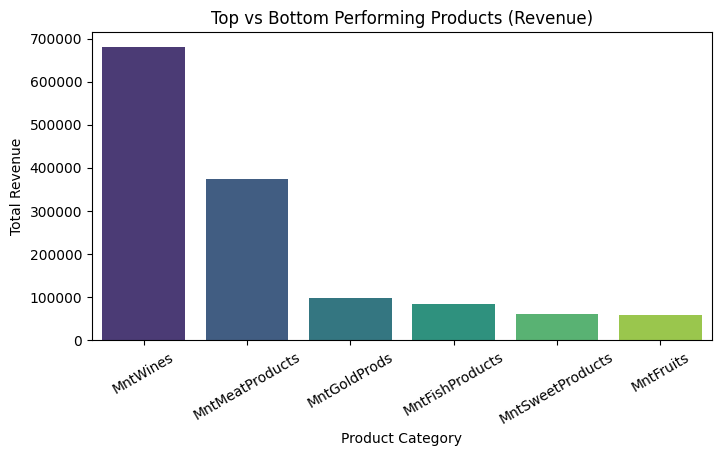

In [230]:
# Let us answer the following questions
# 8.	Use appropriate visualization to help analyze the following:
# a.	Identify the top-performing products and those with the lowest revenue.
# b.	Examine if there is a correlation between customers' age and the acceptance rate of the last campaign.
# c.	Determine the country with the highest number of customers who accepted the last campaign.
# d.	Investigate if there is a discernible pattern in the number of children at home and the total expenditure.
# e.	Analyze the educational background of customers who lodged complaints in the last two years.

#8a
product_columns=['MntFishProducts','MntSweetProducts','MntWines','MntFruits','MntMeatProducts','MntGoldProds']
prod_total = df[product_columns].sum().sort_values(ascending=False)
plt.figure(figsize=(8,4))
sns.barplot(x=prod_total.index, y=prod_total.values, palette="viridis")
plt.title("Top vs Bottom Performing Products (Revenue)")
plt.ylabel("Total Revenue")
plt.xlabel("Product Category")
plt.xticks(rotation=30)
plt.show()
#Clearly wine is the highest selling product

C:\Users\parul\AppData\Local\Temp\ipykernel_5728\2367052034.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acceptance_rate = df.groupby(age_bins)["Response"].mean()


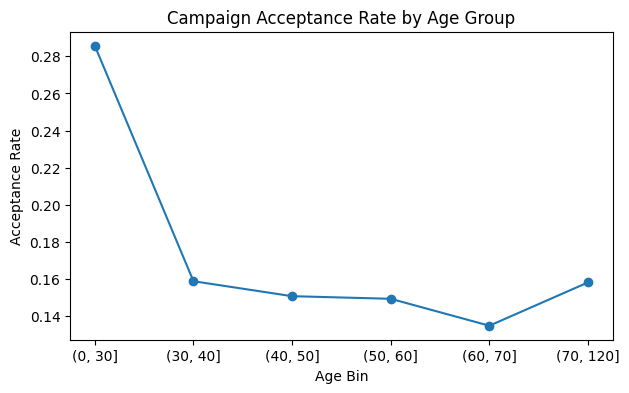

In [231]:
#8b
# We want to see if age influences the likelihood of accepting the last marketing campaign.

# Variable 1: Age (continuous numeric, derived from Year_Birth)
# Variable 2: Response (binary: 1 = accepted, 0 = not accepted)
# Since one variable is numeric (age) and the other is binary (response), we can’t just use a simple correlation matrix. Instead, we check how the acceptance rate changes across age groups.

# Step 1: Create age bins
age_bins = pd.cut(df["Age"], bins=[0,30,40,50,60,70,120])

# Step 2: Compute acceptance rate per bin
acceptance_rate = df.groupby(age_bins)["Response"].mean()

# Step 3: Plot the trend
plt.figure(figsize=(7,4))
acceptance_rate.plot(marker="o")
plt.title("Campaign Acceptance Rate by Age Group")
plt.xlabel("Age Bin")
plt.ylabel("Acceptance Rate")
plt.show()


In [232]:
#There is a negative correlation between customer age and campaign acceptance rate.
#Younger customers are significantly more receptive, while older customers show lower acceptance.

C:\Users\parul\AppData\Local\Temp\ipykernel_5728\4036106146.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accepted_by_country.index, y=accepted_by_country.values, palette="cubehelix")


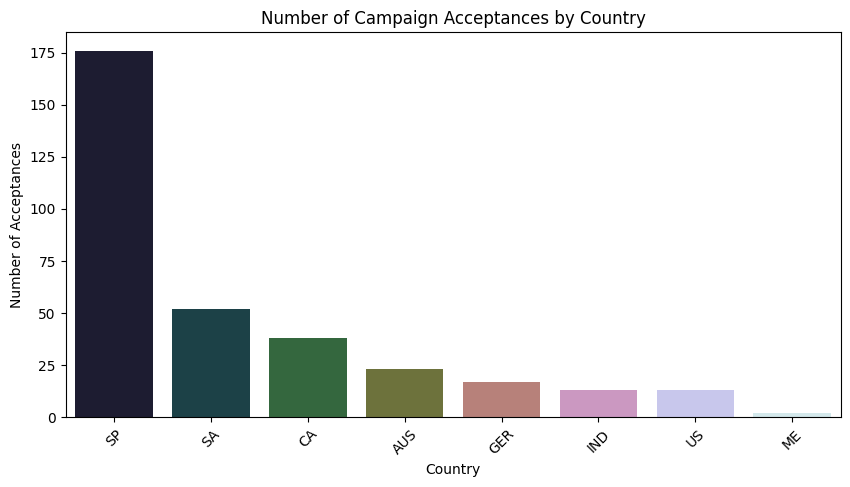

In [233]:
#8c
accepted_by_country = df.loc[df["Response"]==1].groupby("Country")["Response"].count().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=accepted_by_country.index, y=accepted_by_country.values, palette="cubehelix")
plt.title("Number of Campaign Acceptances by Country")
plt.ylabel("Number of Acceptances")
plt.xticks(rotation=45)
plt.show()


In [234]:
#Spain (SP) clearly has the highest number of acceptances (~175 customers).

In [235]:
# Not sure how much of info does having two different columns kidhome and teenhome provide so lets combine them into children
df['Children'] = df['Kidhome'] + df['Teenhome']
df.drop(columns=['Kidhome', 'Teenhome'], inplace=True)

In [236]:
# Now we have also been asked to calculate the total spending across different products and total purchaces from the three channels
df['Total_Spending'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
df.drop(columns=['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds'], inplace=True)

C:\Users\parul\AppData\Local\Temp\ipykernel_5728\1299053030.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=children_spend.index, y=children_spend.values, palette="Set2")


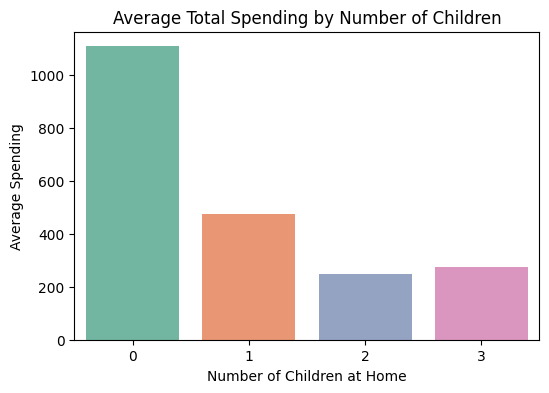

In [237]:
#8d
children_spend = df.groupby("Children")["Total_Spending"].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=children_spend.index, y=children_spend.values, palette="Set2")
plt.title("Average Total Spending by Number of Children")
plt.xlabel("Number of Children at Home")
plt.ylabel("Average Spending")
plt.show()


In [238]:
#People with no children spens the most

C:\Users\parul\AppData\Local\Temp\ipykernel_5728\4074183756.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=complaints_by_edu.index, y=complaints_by_edu.values, palette="magma")


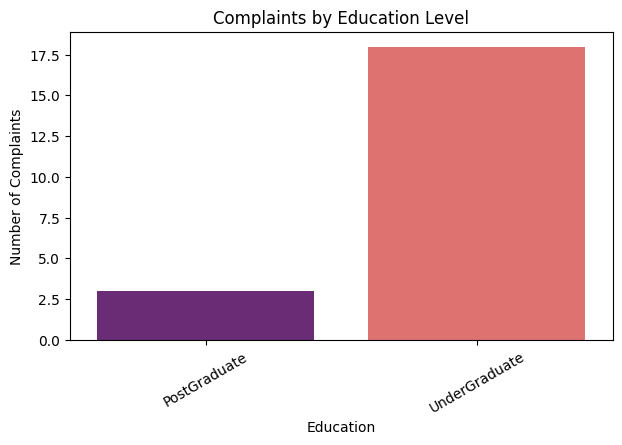

In [239]:
#8e
complaints_by_edu = df.loc[df["Complain"]==1].groupby("Education")["Complain"].count()

plt.figure(figsize=(7,4))
sns.barplot(x=complaints_by_edu.index, y=complaints_by_edu.values, palette="magma")
plt.title("Complaints by Education Level")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=30)
plt.show()


In [240]:
# Undergraduate customers (Basic, 2n Cycle, Graduation) lodged far more complaints (~18).

# Postgraduate customers (Master, PhD) lodged very few complaints (~3).

In [241]:
#7a 
import scipy.stats as stats

# Bin ages
age_bins = pd.cut(df["Age"], [0,30,40,50,60,70,120])

# Mean store purchases per group
store_means = df.groupby(age_bins)["NumStorePurchases"].mean()
print(store_means)

# ANOVA test across groups
anova_result = stats.f_oneway(
    *[df.loc[age_bins == bin_, "NumStorePurchases"].dropna() for bin_ in age_bins.unique()]
)
print("F-statistic:", anova_result.statistic, "p-value:", anova_result.pvalue)



Age
(0, 30]      5.857143
(30, 40]     5.504673
(40, 50]     5.310592
(50, 60]     5.579882
(60, 70]     6.327623
(70, 120]    6.512658
Name: NumStorePurchases, dtype: float64
F-statistic: nan p-value: nan


C:\Users\parul\AppData\Local\Temp\ipykernel_5728\1622824520.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  store_means = df.groupby(age_bins)["NumStorePurchases"].mean()
C:\Users\parul\AppData\Local\Temp\ipykernel_5728\1622824520.py:12: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  anova_result = stats.f_oneway(


In [242]:
#7b

# Define children and online purchases

df["Online_Purchases"] = df["NumWebPurchases"] + df["NumCatalogPurchases"]

# Split groups
with_kids = df.loc[df["Children"] > 0, "Online_Purchases"]
no_kids = df.loc[df["Children"] == 0, "Online_Purchases"]

# Mean comparison
print("Mean Online Purchases (With kids):", with_kids.mean())
print("Mean Online Purchases (No kids):", no_kids.mean())

# T-test
from scipy import stats
t_stat, p_val = stats.ttest_ind(with_kids, no_kids, equal_var=False)
print("t-statistic:", t_stat, "p-value:", p_val)


Mean Online Purchases (With kids): 5.789013732833958
Mean Online Purchases (No kids): 9.152037617554859
t-statistic: -16.059657888487102 p-value: 1.2393876068537248e-52


In [243]:
# This means the hypothesis is NOT supported:
# Customers without children actually make more online purchases than those with children.

In [244]:
#7c
df["NonStorePurchases"] = df["NumWebPurchases"] + df["NumCatalogPurchases"]

r, p_val = stats.pearsonr(df["NumStorePurchases"], df["NonStorePurchases"])
print("Correlation coefficient:", r, "p-value:", p_val)


Correlation coefficient: 0.6153592978630218 p-value: 1.4705856043016368e-233


In [245]:
# The hypothesis of cannibalization (negative correlation) is not supported.

# Instead, channels appear to be complementary:

# Customers who are active shoppers spend across multiple channels (both store and non-store).

# Online shopping is not replacing store shopping — it’s enhancing total sales.

In [246]:
#7d


us_spend = df.loc[df["Country"]=="US", "Total_Spending"]
row_spend = df.loc[df["Country"]!="US", "Total_Spending"]

# --- Step 3: Independent t-test ---
t_stat, p_val = stats.ttest_ind(us_spend, row_spend, equal_var=False)
print("t-statistic:", t_stat, "p-value:", p_val)

t-statistic: 0.3242859580939124 p-value: 0.7462798869022982


In [247]:
# The p-value is much greater than 0.05, meaning the difference in spending between US and non-US customers is not statistically significant.

# The t-statistic is close to zero, confirming that US and ROW averages are nearly identical.

In [248]:
df['Total_Purchaces'] = df['NumCatalogPurchases'] + df['NumStorePurchases'] + df['NumWebPurchases'] 
df.drop(columns=['NumCatalogPurchases','NumStorePurchases','NumWebPurchases'], inplace=True)

In [249]:
df.head()

,ID,Education,Marital_Status,Income,Dt_Customer,Recency,NumDealsPurchases,NumWebVisitsMonth,Response,Complain,Country,Age,OverallCustomerEngagement,Children,Total_Spending,Online_Purchases,NonStorePurchases,Total_Purchaces
0,1826,UnderGraduate,Single,84835.0,4083,0,1,1,1,0,SP,55,1,0,1190,8,8,14
1,1,UnderGraduate,Single,57091.0,4084,0,1,5,1,0,CA,64,2,0,577,10,10,17
2,10476,UnderGraduate,Partnered,67267.0,4117,0,1,2,0,0,US,67,0,1,251,5,5,10
3,1386,UnderGraduate,Partnered,32474.0,4119,0,1,7,0,0,AUS,58,0,2,11,1,1,3
4,5371,UnderGraduate,Single,21474.0,4152,0,2,7,1,0,SP,36,2,1,91,4,4,6


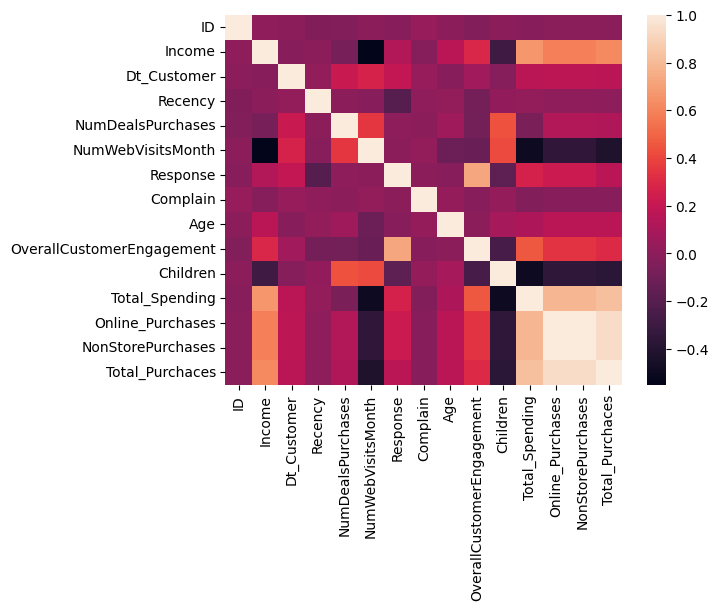

In [250]:
# Choosing only numeric values as correlation doesnt work with categorical data
corr = df.corr(numeric_only=True)

sns.heatmap(corr)
plt.show()

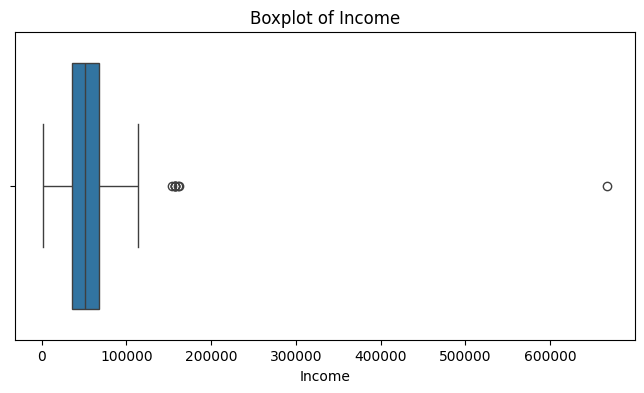

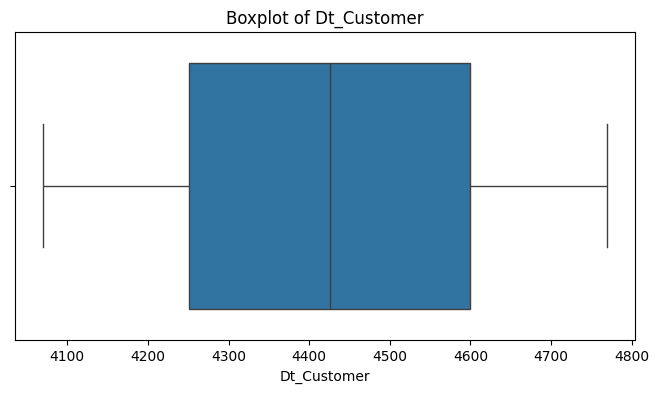

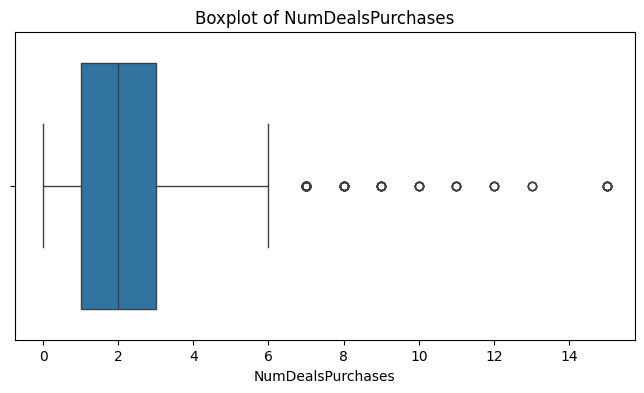

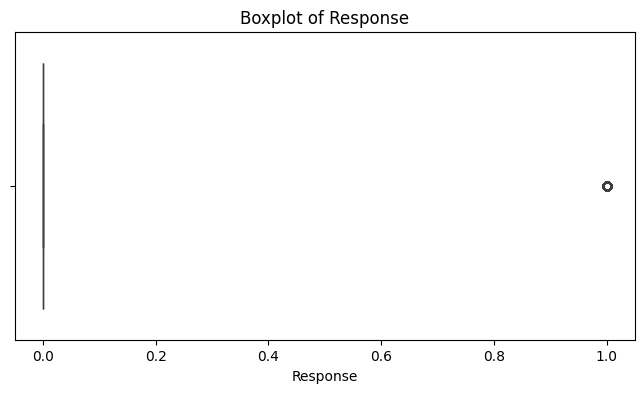

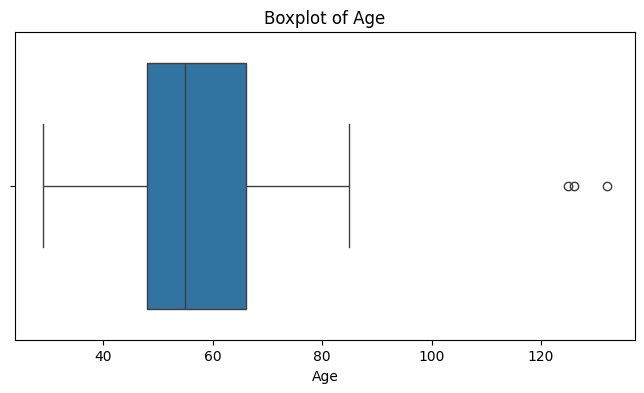

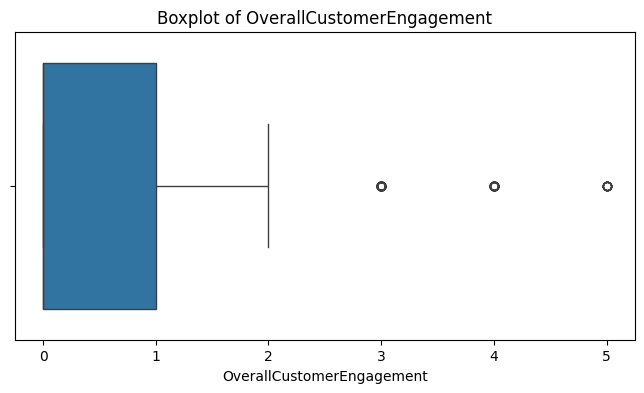

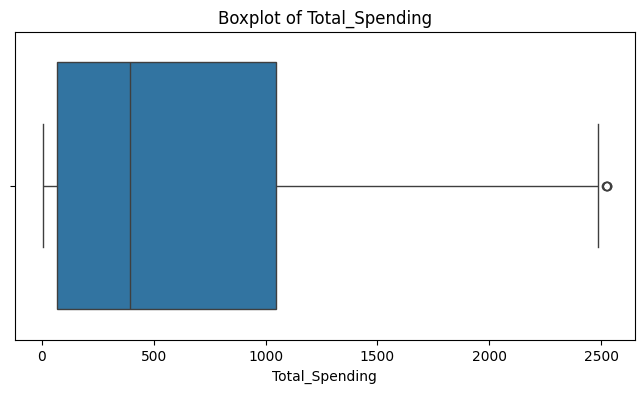

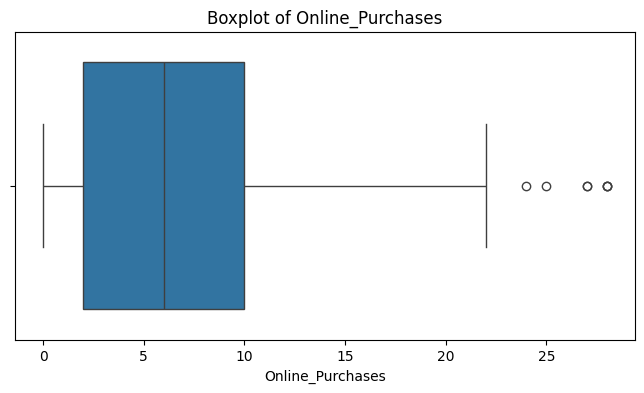

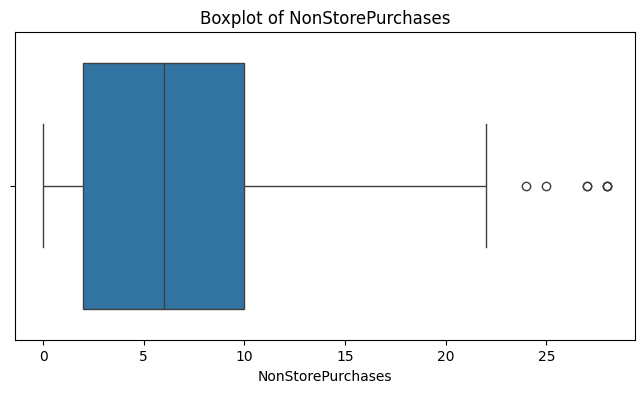

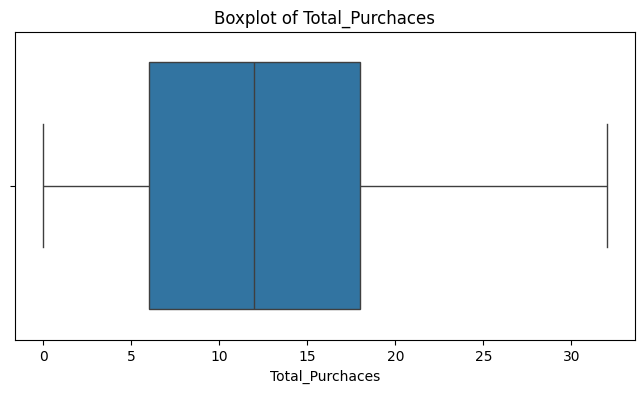

In [251]:
#Now we need to generate box plots and histogram to identify the outliers if any
# Loop through numeric columns
numeric_cols = df.select_dtypes(include='number').columns
columns_to_remove = ['ID', 'Recency','Complain','Customer_tenure_day','Children','NumWebVisitsMonth']
numeric_cols = [col for col in numeric_cols if col not in columns_to_remove]
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [252]:
# Let us do the winsorization of the outliers 
from scipy.stats.mstats import winsorize
import pandas as pd

# Example columns to winsorize
columns_to_winsorize = ['Income', 'Total_Spending', 'Age']

# Create a copy to keep original intact
df_winsorized = df.copy()

# Winsorize each selected column
for col in columns_to_winsorize:
    # Apply winsorization at 5% on both sides
    df_winsorized[col] = winsorize(df[col], limits=[0.05, 0.05])


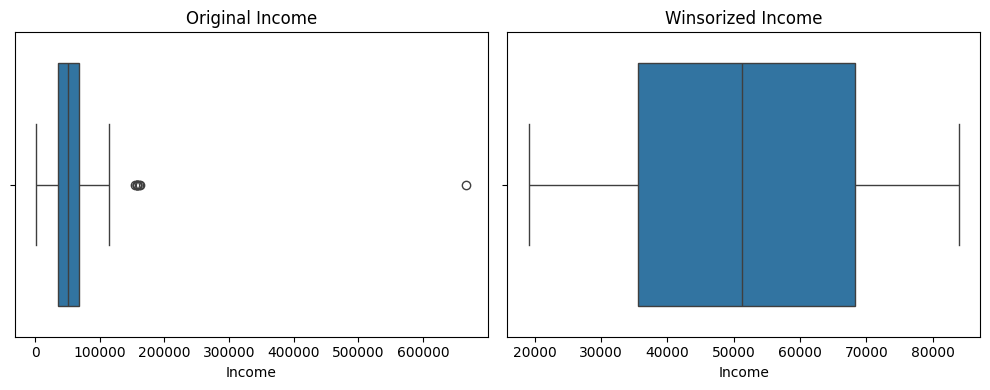

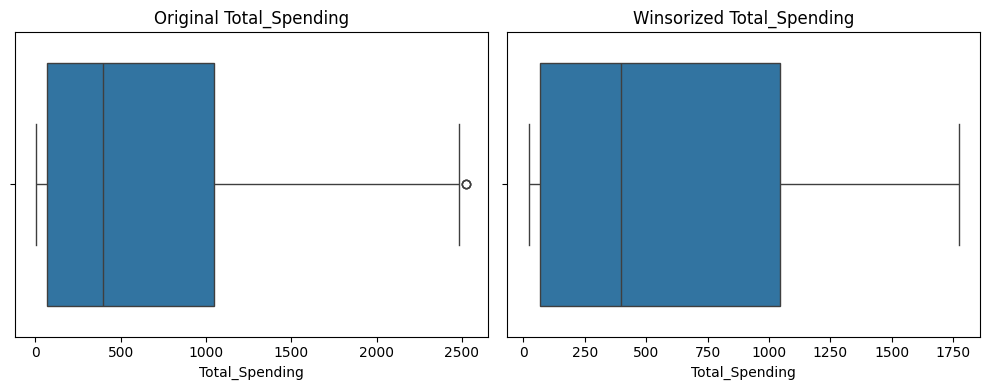

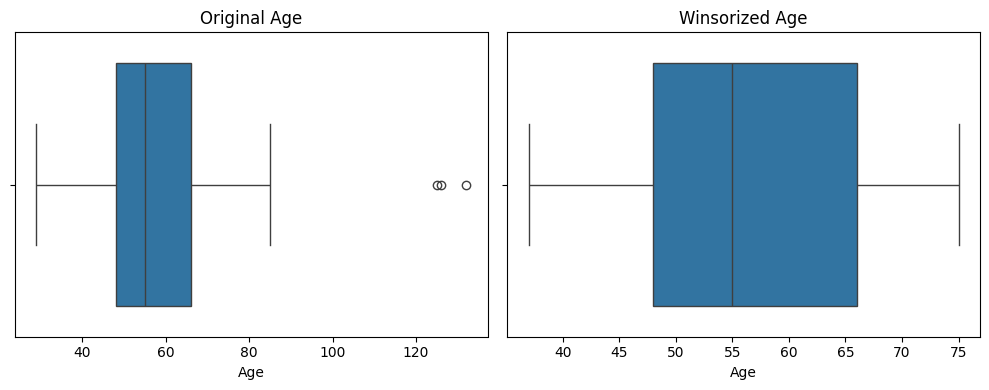

In [253]:
# Compare boxplots
import seaborn as sns
import matplotlib.pyplot as plt

for col in columns_to_winsorize:
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[col])
    plt.title(f'Original {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_winsorized[col])
    plt.title(f'Winsorized {col}')
    
    plt.tight_layout()
    plt.show()


In [254]:
# We’ll apply:

# Ordinal Encoding → for ordered categories (e.g., education levels)

# One-Hot Encoding → for nominal (unordered) categories (e.g., country, marital status)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(categorical_cols)


['Education', 'Marital_Status', 'Country']


In [255]:
education_order = {
    'Basic': 0,
    'Graduation': 1,
    'Master': 2,
    'PhD': 3
}

df['Education'] = df['Education'].map(education_order)


In [256]:
df = pd.get_dummies(df, columns=['Marital_Status', 'Country'], drop_first=True)


In [257]:
df

,ID,Education,Income,Dt_Customer,Recency,NumDealsPurchases,NumWebVisitsMonth,Response,Complain,Age,...,NonStorePurchases,Total_Purchaces,Marital_Status_Single,Country_CA,Country_GER,Country_IND,Country_ME,Country_SA,Country_SP,Country_US
0,1826,NaN,84835.0,4083,0,1,1,1,0,55,...,8,14,True,False,False,False,False,False,True,False
1,1,NaN,57091.0,4084,0,1,5,1,0,64,...,10,17,True,True,False,False,False,False,False,False
2,10476,NaN,67267.0,4117,0,1,2,0,0,67,...,5,10,False,False,False,False,False,False,False,True
3,1386,NaN,32474.0,4119,0,1,7,0,0,58,...,1,3,False,False,False,False,False,False,False,False
4,5371,NaN,21474.0,4152,0,2,7,1,0,36,...,4,6,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,NaN,66476.0,4549,99,2,4,0,0,49,...,7,18,True,False,False,False,False,False,False,True
2236,5263,NaN,31056.0,4593,99,1,8,0,0,48,...,1,4,False,False,False,False,False,False,True,False
2237,22,NaN,46310.0,4643,99,2,8,0,0,49,...,7,12,True,False,False,False,False,False,True,False
2238,528,NaN,65819.0,4647,99,1,3,0,0,47,...,9,19,False,False,False,True,False,False,False,False
